In [45]:
import matplotlib.pyplot as plt
from gen_catalyst_design.db import Database, load_datadicts_from_db
import numpy as np
from ase.io import write

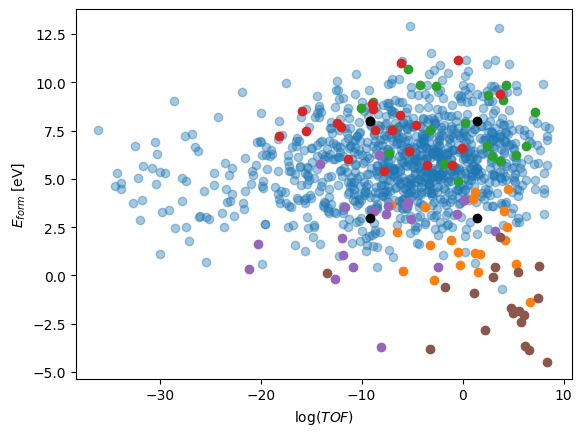

In [77]:
fig, ax = plt.subplots()
ax.set_ylabel(r"$E_{form}$ [eV]")
ax.set_xlabel(r"$\log(TOF)$")

db_train = Database.establish_connection(
    "result_42_seed.db",
    pth_header="../datasets/random_search"
)
train_datadicts = load_datadicts_from_db(database=db_train)
train_rates = np.array([datadict["rate"] for datadict in train_datadicts])
train_e_forms = np.array([datadict["e_form"] for datadict in train_datadicts])

ax.scatter(np.log(train_rates), train_e_forms, c="C0", alpha=0.4)

rate_cond = 0.5
e_form_cond = 3.0

rate_conds = [4.0, 0.0001]
e_form_conds = [3.0, 8.0]
i=1
for rate_cond in rate_conds:
    for e_form_cond in e_form_conds:
        db_pred = Database.establish_connection(
        f"joint_evals_{i}.db",#f"e_form_{e_form_cond}_evals.db",#f"rate_{rate_cond}_evals.db",
        pth_header="rate_eform_testing/test_log_rate/samples"
        )
        pred_datadicts = load_datadicts_from_db(database=db_pred)
        pred_rates = np.array([datadict["rate"] for datadict in pred_datadicts])
        pred_e_forms = np.array([datadict["e_form"] for datadict in pred_datadicts])
        ax.scatter(np.log(pred_rates), pred_e_forms, c=f"C{i}")
        ax.plot(np.log(rate_cond), e_form_cond, "o", c="k")
        i+=1
db_pred = Database.establish_connection(
    f"joint_evals_{5}.db",#f"e_form_{e_form_cond}_evals.db",#f"rate_{rate_cond}_evals.db",
    pth_header="rate_eform_testing/test_log_rate/samples"
)
pred_datadicts = load_datadicts_from_db(database=db_pred)
pred_rates = np.array([datadict["rate"] for datadict in pred_datadicts])
pred_e_forms = np.array([datadict["e_form"] for datadict in pred_datadicts])
ax.scatter(np.log(pred_rates), pred_e_forms, c=f"C{i}")
ax.plot(np.log(rate_cond), e_form_cond, "o", c="k")

#ax.vlines(x=np.log(0.0001), ymax=10, ymin=0.0)

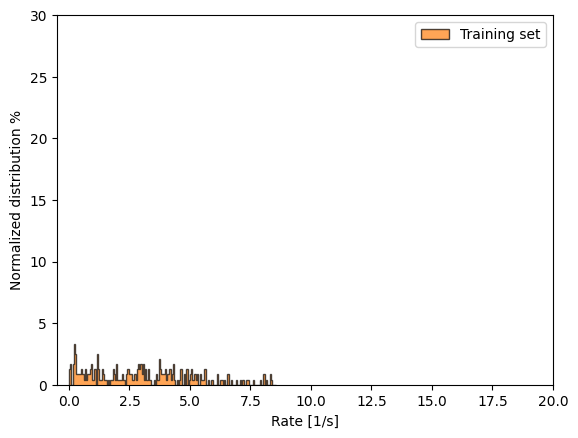

In [41]:
fig, ax = plt.subplots()

rate_interval = 0.05
rate_max = np.log(np.max(train_rates))
rate_min = 0.0

i = 0
hist_prior = None
y_lims = 0.30*100
labels = [
    "Training set",
    "Sampled rates"
]

step = 2.5
classes = np.arange(1.0, np.ceil(rate_max)+step, step)#np.linspace(1.0, np.ceil(rate_max), 5)
for rates, color, label in zip([np.log(train_rates)], ["C1", "C0"], labels):
    bins = np.arange(rate_min, rate_max, rate_interval)
    hist, edges = np.histogram(rates, bins=bins)
    hist_norm = hist/np.sum(hist)
    ax.stairs(hist_norm*100, edges=edges, fill=True, alpha=0.7, edgecolor="k", linewidth=1, color=color, label=label)
    ax.set_xlim([-0.5, 20.0])#np.ceil(rate_max)+step])
    ax.set_ylim([0.0, y_lims])
    ax.set_ylabel("Normalized distribution %")
    ax.set_xlabel("Rate [1/s]")
ax.legend()

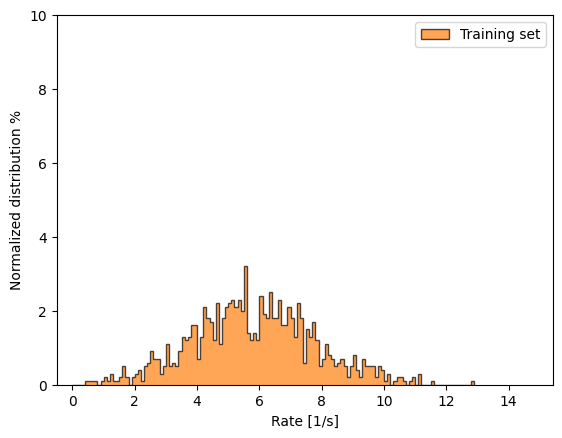

In [38]:
fig, ax = plt.subplots()

e_form_interval = 0.1
e_form_max = np.max(train_e_forms)
e_form_min = 0.0

i = 0
hist_prior = None
y_lims = 0.1*100
labels = [
    "Training set",
    "Sampled rates"
]

step = 2.5
classes = np.arange(1.0, np.ceil(e_form_max)+step, step)#np.linspace(1.0, np.ceil(rate_max), 5)
for e_forms, color, label in zip([train_e_forms], ["C1", "C0"], labels):
    bins = np.arange(e_form_min, e_form_max, e_form_interval)
    hist, edges = np.histogram(e_forms, bins=bins)
    hist_norm = hist/np.sum(hist)
    ax.stairs(hist_norm*100, edges=edges, fill=True, alpha=0.7, edgecolor="k", linewidth=1, color=color, label=label)
    ax.set_xlim([-0.5, e_form_max+step])#np.ceil(rate_max)+step])
    ax.set_ylim([0.0, y_lims])
    ax.set_ylabel("Normalized distribution %")
    ax.set_xlabel("Rate [1/s]")
ax.legend()

In [11]:
print(np.max(rates), np.min(rates))
print(np.max(e_forms), np.min(e_forms))

5230.32692485898 1.0996724269230026e-15
12.801712 0.42851257


In [14]:
np.exp(9)

np.float64(8103.083927575384)

In [15]:
np.max(rates)*0.9

np.float64(4707.294232373082)